# Прогноз потребления алкоголя в пересчёте на банки Guinness

В работе используется годовой ряд России из World Bank WDI: `WB_WDI_SH_ALC_PCAP_LI.csv`.
Исходная единица измерения — литры чистого алкоголя на человека 15+ в год.
Для интерпретации ряд переводится в **банки Guinness 440 мл, 4.2% ABV**.

Формально в задании упомянут ежемесячный ряд, но здесь осознанно используется годовая частота:
пользователь явно разрешил не привязываться к месячной грануляции. Из-за этого настоящей внутригодовой
сезонности нет, а «сезонные» шаги ниже интерпретируются как квази-сезонные лаговые разности.

Обозначим через $L_t$ потребление чистого алкоголя в литрах на человека в году $t$, а через $Y_t$ —
тот же показатель в банках Guinness. Тогда аналитическая задача состоит в построении прогноза
$\hat{Y}_{2030}$ и его интерпретации в прикладных терминах.


## 1. Импорт библиотек и настройка


In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import zscore
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

plt.style.use("tableau-colorblind10")
plt.rcParams["figure.figsize"] = (12, 5)
pd.options.display.float_format = "{:,.2f}".format
warnings.filterwarnings("ignore", category=ConvergenceWarning)


## 2. Подготовка ряда

Одна банка Guinness содержит `440 * 0.042 = 18.48 мл` чистого алкоголя.
Значит, годовое потребление в литрах переводится в количество банок через деление на `0.01848`.

Формально:

$$
a_{can} = 440 \\cdot 0.042 = 18.48 \\text{ мл этанола},
$$

$$
Y_t = \\frac{1000 \\cdot L_t}{a_{can}}.
$$

Если нужен пересчёт в граммы чистого этанола, используем плотность $\\rho = 0.789$ г/мл:

$$
g_{can} = a_{can} \\cdot \\rho.
$$


In [2]:
DATA_PATH = "WB_WDI_SH_ALC_PCAP_LI.csv"
COUNTRY_CODE = "RUS"
GUINNESS_CAN_ML = 440
GUINNESS_ABV = 0.042
ETHANOL_DENSITY_G_PER_ML = 0.789
PURE_ALCOHOL_PER_CAN_ML = GUINNESS_CAN_ML * GUINNESS_ABV
PURE_ALCOHOL_PER_CAN_G = PURE_ALCOHOL_PER_CAN_ML * ETHANOL_DENSITY_G_PER_ML
TEST_HORIZON = 5
TARGET_YEAR = 2030
BODY_WEIGHT_KG = 73
LETHAL_DOSE_G_PER_KG_LOW = 5.0
LETHAL_DOSE_G_PER_KG_HIGH = 6.0
QUASI_SEASONAL_LAG = 2
STL_PERIOD = 3
RF_LAGS = 3
RANDOM_STATE = 42

raw = pd.read_csv(DATA_PATH)

ts = (
    raw.loc[raw["REF_AREA"] == COUNTRY_CODE, ["TIME_PERIOD", "OBS_VALUE"]]
    .dropna()
    .rename(columns={"TIME_PERIOD": "year", "OBS_VALUE": "alcohol_liters"})
    .sort_values("year")
    .reset_index(drop=True)
)

ts["date"] = pd.to_datetime(ts["year"].astype(str), format="%Y")
ts["guinness_cans"] = ts["alcohol_liters"] * 1000.0 / PURE_ALCOHOL_PER_CAN_ML
ts = ts.set_index("date").asfreq("YS")

series = ts["guinness_cans"].astype(float)
log_series = np.log(series)
first_diff = series.diff()
quasi_seasonal_diff = series.diff(QUASI_SEASONAL_LAG)
FORECAST_HORIZON = TARGET_YEAR - series.index.max().year

display(ts.head())
print(f"Наблюдений: {len(series)}")
print(f"Период: {series.index.min().year}–{series.index.max().year}")
print(f"Среднее потребление: {series.mean():.2f} банок Guinness в год на человека 15+")
print(f"Горизонт итогового прогноза: до {TARGET_YEAR} года ({FORECAST_HORIZON} шагов)")


,year,alcohol_liters,guinness_cans
date,,,
2000-01-01,2000,13.86,750.00
2001-01-01,2001,13.86,750.00
2002-01-01,2002,14.12,764.07
2003-01-01,2003,14.33,775.43
2004-01-01,2004,14.45,781.93


Наблюдений: 21
Период: 2000–2020
Среднее потребление: 704.49 банок Guinness в год на человека 15+
Горизонт итогового прогноза: до 2030 года (10 шагов)


## 3. Визуализация ряда, разностей и компонент

Для годового ряда обычная разность естественна, а лаговая разность с лагом 2 используется как
квази-сезонная: не как календарная сезонность, а как способ проверить наличие двухлетней цикличности.
STL-разложение ниже тоже нужно трактовать аккуратно: тренд и остаток интерпретируются надёжно,
а «seasonal» компонент здесь отражает короткие колебания, а не месячный сезонный паттерн.

Используются преобразования:

$$
\\Delta Y_t = Y_t - Y_{t-1},
$$

$$
\\Delta_{(2)} Y_t = Y_t - Y_{t-2},
$$

а также STL-разложение

$$
Y_t = T_t + S_t + R_t,
$$

где $T_t$ — тренд, $S_t$ — короткая циклическая компонента, $R_t$ — остаток.


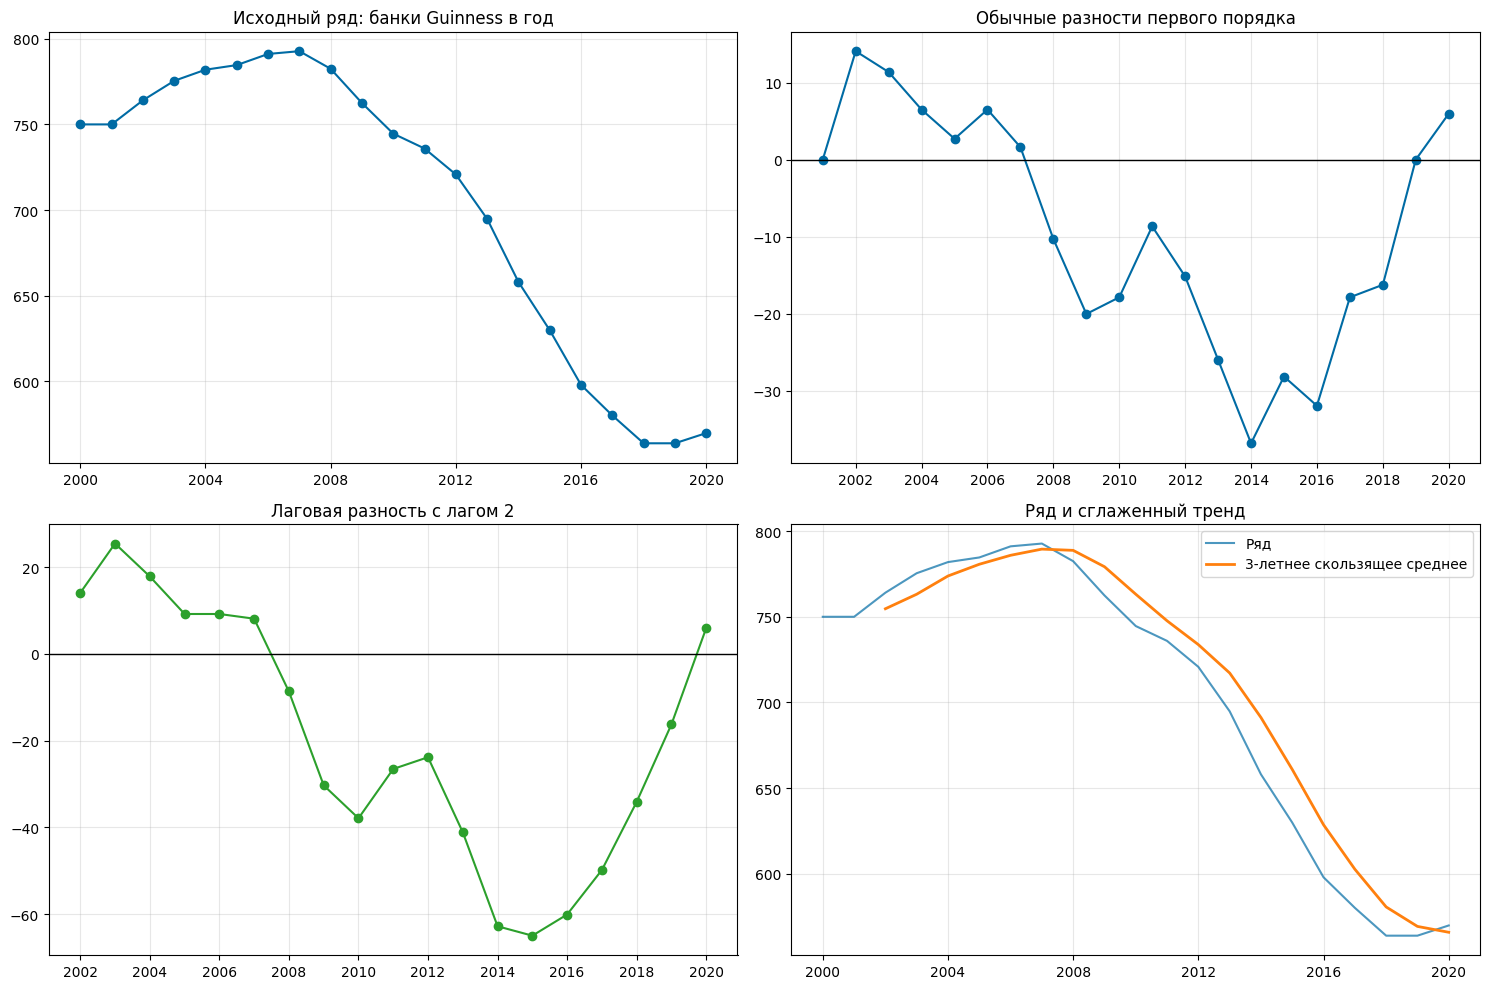

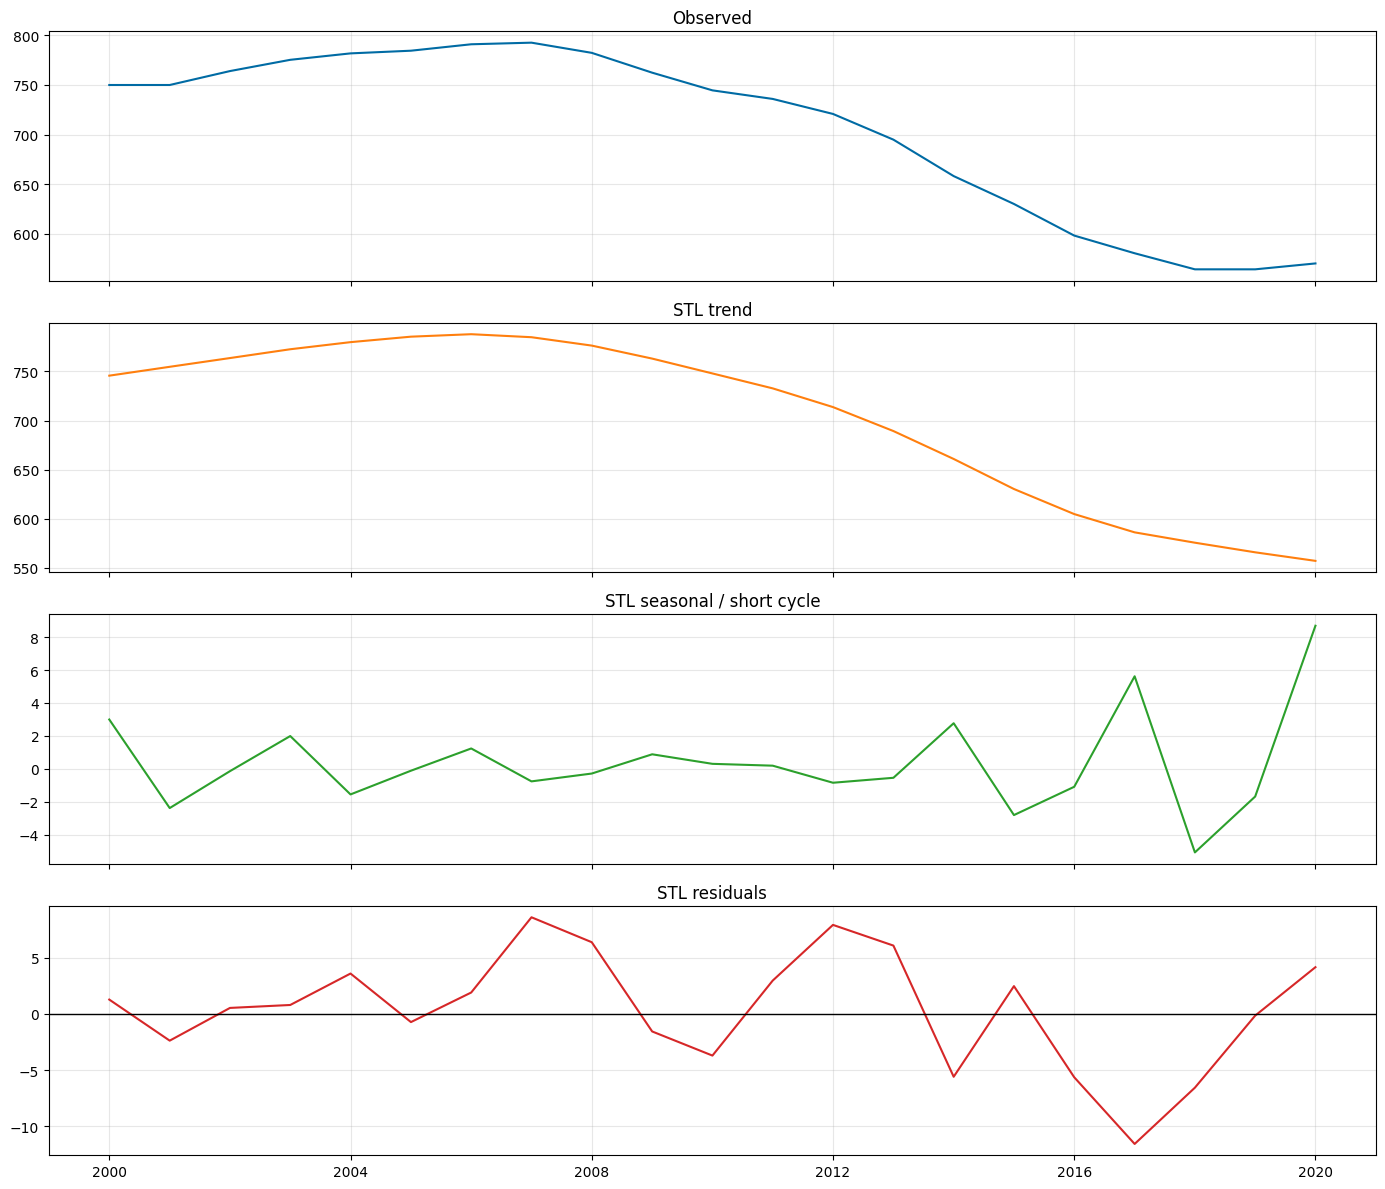

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(series.index, series, marker="o")
axes[0, 0].set_title("Исходный ряд: банки Guinness в год")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(first_diff.index, first_diff, marker="o")
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("Обычные разности первого порядка")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(quasi_seasonal_diff.index, quasi_seasonal_diff, marker="o", color="tab:green")
axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set_title(f'Лаговая разность с лагом {QUASI_SEASONAL_LAG}')
axes[1, 0].grid(alpha=0.3)

rolling_mean = series.rolling(3).mean()
axes[1, 1].plot(series.index, series, label="Ряд", alpha=0.7)
axes[1, 1].plot(rolling_mean.index, rolling_mean, label="3-летнее скользящее среднее", linewidth=2)
axes[1, 1].set_title("Ряд и сглаженный тренд")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

stl = STL(series, period=STL_PERIOD, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].plot(series.index, series)
axes[0].set_title("Observed")
axes[0].grid(alpha=0.3)

axes[1].plot(stl.trend.index, stl.trend, color="tab:orange")
axes[1].set_title("STL trend")
axes[1].grid(alpha=0.3)

axes[2].plot(stl.seasonal.index, stl.seasonal, color="tab:green")
axes[2].set_title("STL seasonal / short cycle")
axes[2].grid(alpha=0.3)

axes[3].plot(stl.resid.index, stl.resid, color="tab:red")
axes[3].axhline(0, color="black", linewidth=1)
axes[3].set_title("STL residuals")
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Комментарий к графикам.**

1. Исходный ряд имеет выраженный восходящий участок до 2007 года и затем устойчивое снижение, то есть средний уровень во времени меняется.
2. После первой разности тренд в значительной степени исчезает, а колебания становятся ближе к стационарным.
3. Лаговая разность с лагом 2 не показывает устойчивой циклической структуры: это дополнительная проверка, а не настоящая сезонность.
4. STL подтверждает, что основную динамику формирует тренд, а короткие колебания и остаток заметно слабее трендовой компоненты.


## 4. ACF и PACF

Для ряда $Y_t$ оцениваются выборочная автокорреляционная функция

$$
\\rho(k) = \\text{Corr}(Y_t, Y_{t-k}),
$$

и частная автокорреляционная функция, которая показывает связь между $Y_t$ и $Y_{t-k}$
после исключения влияния промежуточных лагов. Эти графики помогают выбрать порядок ARIMA-модели.


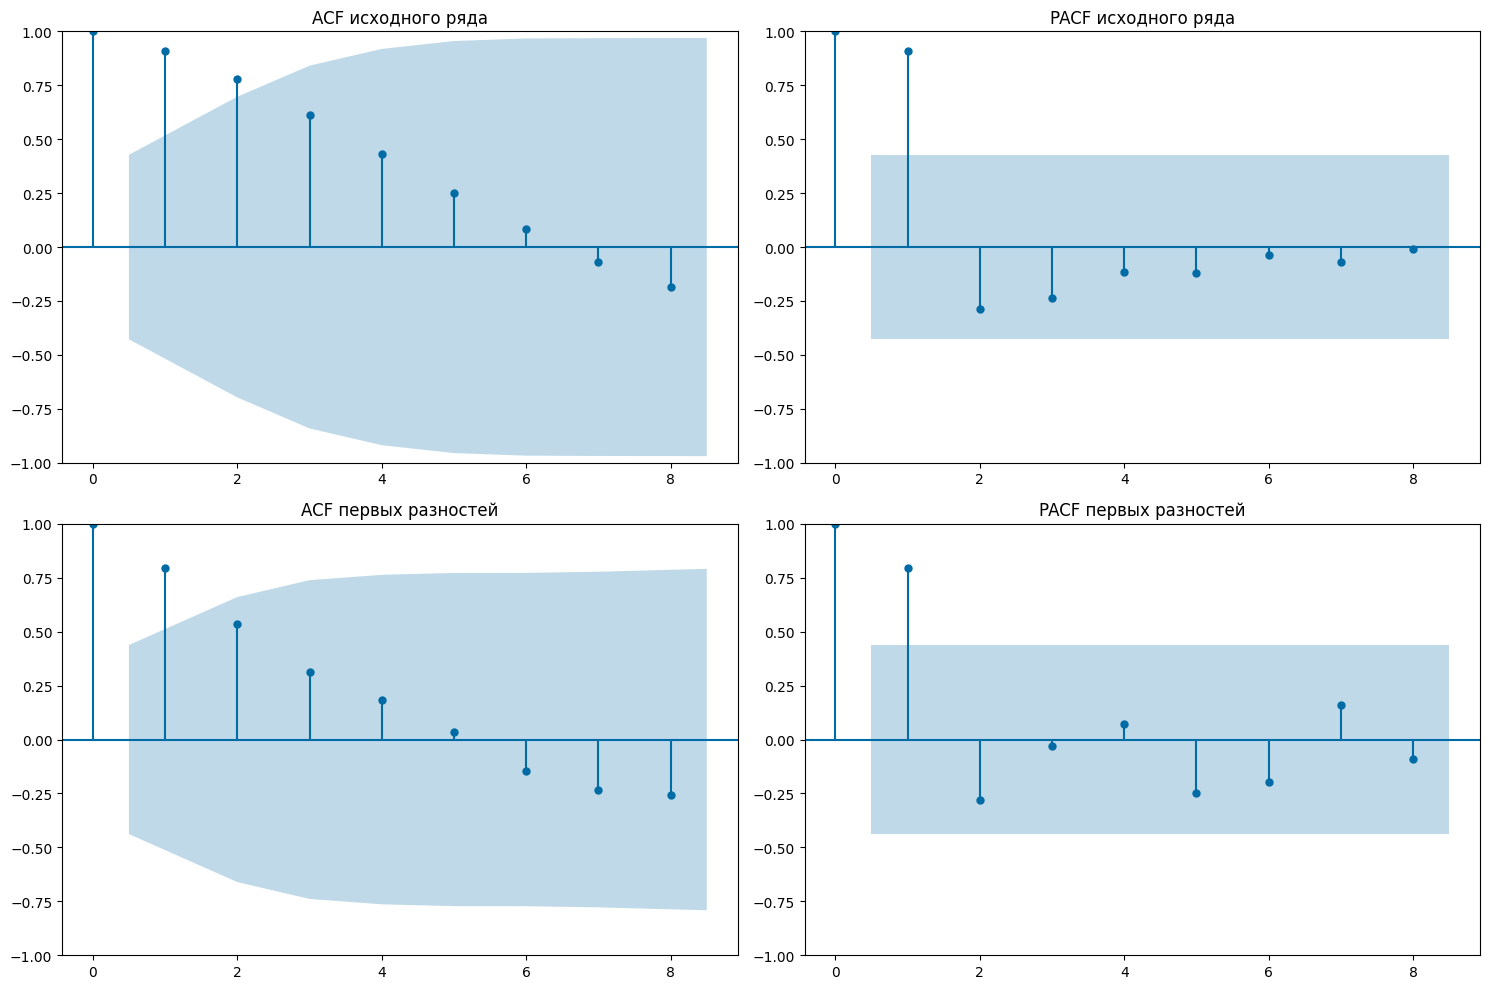

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_acf(series, ax=axes[0, 0], lags=min(8, len(series) - 1))
axes[0, 0].set_title("ACF исходного ряда")

plot_pacf(series, ax=axes[0, 1], lags=min(8, len(series) // 2 - 1), method="ywm")
axes[0, 1].set_title("PACF исходного ряда")

plot_acf(first_diff.dropna(), ax=axes[1, 0], lags=min(8, len(first_diff.dropna()) - 1))
axes[1, 0].set_title("ACF первых разностей")

plot_pacf(first_diff.dropna(), ax=axes[1, 1], lags=min(8, len(first_diff.dropna()) // 2 - 1), method="ywm")
axes[1, 1].set_title("PACF первых разностей")

plt.tight_layout()
plt.show()


**Комментарий к ACF/PACF.**

1. У исходного ряда автокорреляции затухают медленно, что типично для нестационарного ряда с трендом.
2. После обычного дифференцирования автокорреляционная структура становится короче, что поддерживает идею перехода к стационарности.
3. PACF первых разностей допускает компактную ARIMA-спецификацию невысокого порядка; это будет использовано при подборе SARIMA.


## 5. Проверка стационарности

Проверка проводится двумя комплементарными тестами:

1. `ADF`: $H_0$ — ряд имеет единичный корень и нестационарен.
2. `KPSS`: $H_0$ — ряд стационарен относительно константы.

Совместное использование удобно на коротких выборках, где один тест может быть недостаточно мощным.


In [5]:
def adf_report(x: pd.Series, name: str) -> dict:
    stat, pvalue, usedlag, nobs, critical_values, *_ = adfuller(x.dropna(), autolag="AIC")
    return {
        "series": name,
        "adf_stat": stat,
        "p_value": pvalue,
        "lags_used": usedlag,
        "nobs": nobs,
        "critical_5%": critical_values["5%"],
        "stationary_at_5%": pvalue < 0.05,
    }

def kpss_report(x: pd.Series, name: str) -> dict:
    stat, pvalue, used_lags, critical_values = kpss(x.dropna(), regression="c", nlags="auto")
    return {
        "series": name,
        "kpss_stat": stat,
        "p_value": pvalue,
        "lags_used": used_lags,
        "critical_5%": critical_values["5%"],
        "stationary_at_5%": pvalue >= 0.05,
    }

adf_results = pd.DataFrame([
    adf_report(series, "Исходный ряд"),
    adf_report(first_diff, "Первые разности"),
])
kpss_results = pd.DataFrame([
    kpss_report(series, "Исходный ряд"),
    kpss_report(first_diff, "Первые разности"),
])

print("ADF: нулевая гипотеза — единичный корень.")
display(adf_results)
print("KPSS: нулевая гипотеза — стационарность.")
display(kpss_results)


ADF: нулевая гипотеза — единичный корень.


,series,adf_stat,p_value,lags_used,nobs,critical_5%,stationary_at_5%
0,Исходный ряд,-2.68,0.08,8,12,-3.15,False
1,Первые разности,-0.93,0.78,7,12,-3.15,False


KPSS: нулевая гипотеза — стационарность.


,series,kpss_stat,p_value,lags_used,critical_5%,stationary_at_5%
0,Исходный ряд,0.66,0.02,2,0.46,False
1,Первые разности,0.39,0.08,2,0.46,True


**Вывод по стационарности.**

Исходный ряд нестационарен: ADF не отвергает единичный корень, а KPSS отвергает стационарность.
Для первых разностей ADF на короткой выборке остаётся слабым, но KPSS уже не отвергает стационарность.
Поэтому в практическом моделировании разумно считать ряд интегрированным порядка 1 и работать с разностями / ARIMA-подходом.


## 6. Преобразование ряда

Применим логарифмирование. Причины:

1. ряд строго положителен;
2. логарифм удобен для интерпретации относительных изменений;
3. модели на лог-шкале дают положительные прогнозы после обратного преобразования.

Преобразование имеет вид

$$
Z_t = \\log Y_t.
$$

После построения прогноза на лог-шкале выполняется обратный переход:

$$
\\hat{Y}_t = e^{\\hat{Z}_t}.
$$


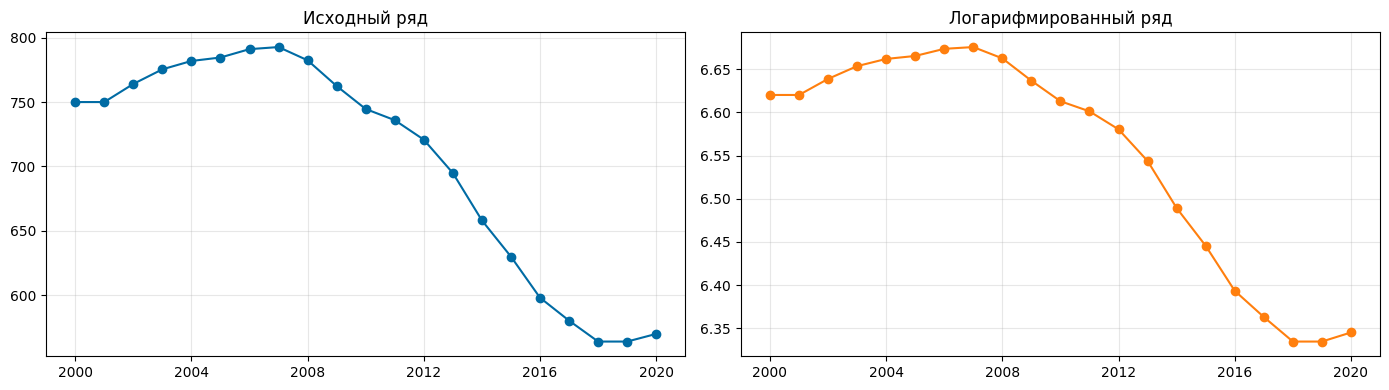

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series, marker="o")
axes[0].set_title("Исходный ряд")
axes[0].grid(alpha=0.3)

axes[1].plot(log_series.index, log_series, marker="o", color="tab:orange")
axes[1].set_title("Логарифмированный ряд")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Деление на train/test

Ряд делится по времени без перемешивания:

$$
\\{Y_1, \\dots, Y_T\\} = \\underbrace{\\{Y_1, \\dots, Y_{T-h}\\}}_{train} \\cup
\\underbrace{\\{Y_{T-h+1}, \\dots, Y_T\\}}_{test},
$$

где $h=5$ — длина тестового горизонта.


In [7]:
train = series.iloc[:-TEST_HORIZON].copy()
test = series.iloc[-TEST_HORIZON:].copy()

train_log = np.log(train)
test_log = np.log(test)

print("Train:", train.index.min().year, "–", train.index.max().year, f"({len(train)} наблюдений)")
print("Test :", test.index.min().year, "–", test.index.max().year, f"({len(test)} наблюдений)")


Train: 2000 – 2015 (16 наблюдений)
Test : 2016 – 2020 (5 наблюдений)


## 8. Оценка моделей на обучающей выборке

Рассматриваются:

1. `Naive`;
2. `ETS`;
3. `SARIMA`;
4. `Random Forest` по лаговым признакам;
5. `Theta`;
6. усреднение трёх лидеров.

Краткие формулы моделей:

1. `Naive`:
$$
\\hat{Y}_{t+1|t} = Y_t.
$$

2. `ETS` с трендом:
$$
\\hat{Y}_{t+h|t} = \\ell_t + h b_t,
$$
где $\\ell_t$ — уровень, $b_t$ — тренд.

3. `SARIMA` в нашем случае вырождается в несезонную ARIMA-структуру для лог-ряда:
$$
\\phi(B)(1-B)^d Z_t = c + \\theta(B)\\varepsilon_t.
$$

4. `Random Forest` использует лаговые признаки
$$
X_t = (Z_{t-1}, Z_{t-2}, Z_{t-3}).
$$

5. `Theta` раскладывает ряд на theta-линии и комбинирует их прогнозы.

6. Ансамбль лидеров:
$$
\\hat{Y}^{ens}_t = \\frac{1}{m}\\sum_{j=1}^m \\hat{Y}^{(j)}_t.
$$

Критерии качества:

$$
MAE = \\frac{1}{n}\\sum_{t=1}^{n} |Y_t - \\hat{Y}_t|,
$$

$$
RMSE = \\sqrt{\\frac{1}{n}\\sum_{t=1}^{n}(Y_t - \\hat{Y}_t)^2},
$$

$$
\\operatorname{MAPE} = \\frac{100}{n}\\sum_{t=1}^{n}\\left|\\frac{Y_t-\\hat{Y}_t}{Y_t}\\right|,
$$

где итог интерпретируется в процентах.


In [8]:
def future_index_from_last(last_timestamp: pd.Timestamp, horizon: int) -> pd.DatetimeIndex:
    return pd.date_range(last_timestamp, periods=horizon + 1, freq="YS")[1:]


def to_level(log_forecast, index):
    return pd.Series(np.exp(np.asarray(log_forecast, dtype=float)), index=index)


def evaluate_forecast(model_name: str, y_true: pd.Series, y_pred: pd.Series) -> dict:
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": (np.abs((y_true - y_pred) / y_true).mean() * 100),
    }


def fit_naive(train_log: pd.Series, horizon: int):
    index = future_index_from_last(train_log.index[-1], horizon)
    pred = pd.Series(np.repeat(train_log.iloc[-1], horizon), index=index)
    return {"fit": None, "forecast_log": pred}


def fit_ets(train_log: pd.Series, horizon: int):
    model = ExponentialSmoothing(
        train_log,
        trend="add",
        damped_trend=True,
        seasonal=None,
        initialization_method="estimated",
    )
    fit = model.fit(optimized=True, use_brute=True)
    pred = pd.Series(fit.forecast(horizon), index=future_index_from_last(train_log.index[-1], horizon))
    return {"fit": fit, "forecast_log": pred}


SARIMA_CANDIDATES = [
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 0),
    (0, 1, 2),
    (2, 1, 1),
]


def fit_best_sarima(train_log: pd.Series, horizon: int):
    fitted_models = []
    for order in SARIMA_CANDIDATES:
        fitted = SARIMAX(
            train_log,
            order=order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        fitted_models.append((order, fitted.aic, fitted))

    best_order, best_aic, best_fit = min(fitted_models, key=lambda item: item[1])
    pred = pd.Series(
        best_fit.get_forecast(steps=horizon).predicted_mean,
        index=future_index_from_last(train_log.index[-1], horizon),
    )
    aic_table = pd.DataFrame(
        [{"order": str(order), "AIC": aic} for order, aic, _ in fitted_models]
    ).sort_values("AIC")
    return {"fit": best_fit, "forecast_log": pred, "order": best_order, "aic_table": aic_table}


def fit_theta(train_log: pd.Series, horizon: int):
    fit = ThetaModel(train_log, period=1, deseasonalize=False).fit()
    pred = pd.Series(fit.forecast(horizon), index=future_index_from_last(train_log.index[-1], horizon))
    return {"fit": fit, "forecast_log": pred}


def make_lagged_matrix(series_log: pd.Series, lags: int = RF_LAGS) -> pd.DataFrame:
    frame = pd.DataFrame({"y": series_log})
    for lag in range(1, lags + 1):
        frame[f"lag_{lag}"] = frame["y"].shift(lag)
    return frame.dropna()


def fit_random_forest(train_log: pd.Series, horizon: int, lags: int = RF_LAGS):
    frame = make_lagged_matrix(train_log, lags=lags)
    x_train = frame.drop(columns="y")
    y_train = frame["y"]

    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=4,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
    )
    rf.fit(x_train, y_train)

    history = train_log.tolist()
    preds = []
    for _ in range(horizon):
        features = np.array(history[-lags:][::-1]).reshape(1, -1)
        next_value = rf.predict(features)[0]
        preds.append(next_value)
        history.append(next_value)

    pred = pd.Series(preds, index=future_index_from_last(train_log.index[-1], horizon))
    return {"fit": rf, "forecast_log": pred}


fitted_models = {
    "Naive": fit_naive(train_log, len(test)),
    "ETS": fit_ets(train_log, len(test)),
    "SARIMA": fit_best_sarima(train_log, len(test)),
    "RandomForest": fit_random_forest(train_log, len(test)),
    "Theta": fit_theta(train_log, len(test)),
}

sarima_aic_table = fitted_models["SARIMA"]["aic_table"]
best_sarima_order = fitted_models["SARIMA"]["order"]

pred_levels = {
    name: to_level(result["forecast_log"], test.index)
    for name, result in fitted_models.items()
}

metrics = pd.DataFrame(
    [evaluate_forecast(name, test, forecast) for name, forecast in pred_levels.items()]
).sort_values("MAE")

leader_names = metrics.head(3)["model"].tolist()
ensemble_forecast = pd.concat([pred_levels[name] for name in leader_names], axis=1).mean(axis=1)
pred_levels["Ensemble"] = ensemble_forecast

metrics = pd.DataFrame(
    [evaluate_forecast(name, test, forecast) for name, forecast in pred_levels.items()]
).sort_values("MAE").reset_index(drop=True)

print("Лучший порядок SARIMA по AIC на train:", best_sarima_order)
display(sarima_aic_table)
display(metrics)


Лучший порядок SARIMA по AIC на train: (1, 1, 0)


,order,AIC
1,"(1, 1, 0)",-81.04
3,"(1, 1, 1)",-78.86
4,"(2, 1, 0)",-78.04
6,"(2, 1, 1)",-76.13
5,"(0, 1, 2)",-72.41
2,"(0, 1, 1)",-72.28
0,"(0, 1, 0)",-63.23


,model,MAE,RMSE,MAPE_%
0,Ensemble,14.30,16.31,2.49
1,ETS,22.82,32.02,4.01
2,SARIMA,26.94,37.10,4.74
3,Theta,45.36,46.39,7.93
4,Naive,54.76,56.25,9.58
5,RandomForest,68.62,69.81,11.99


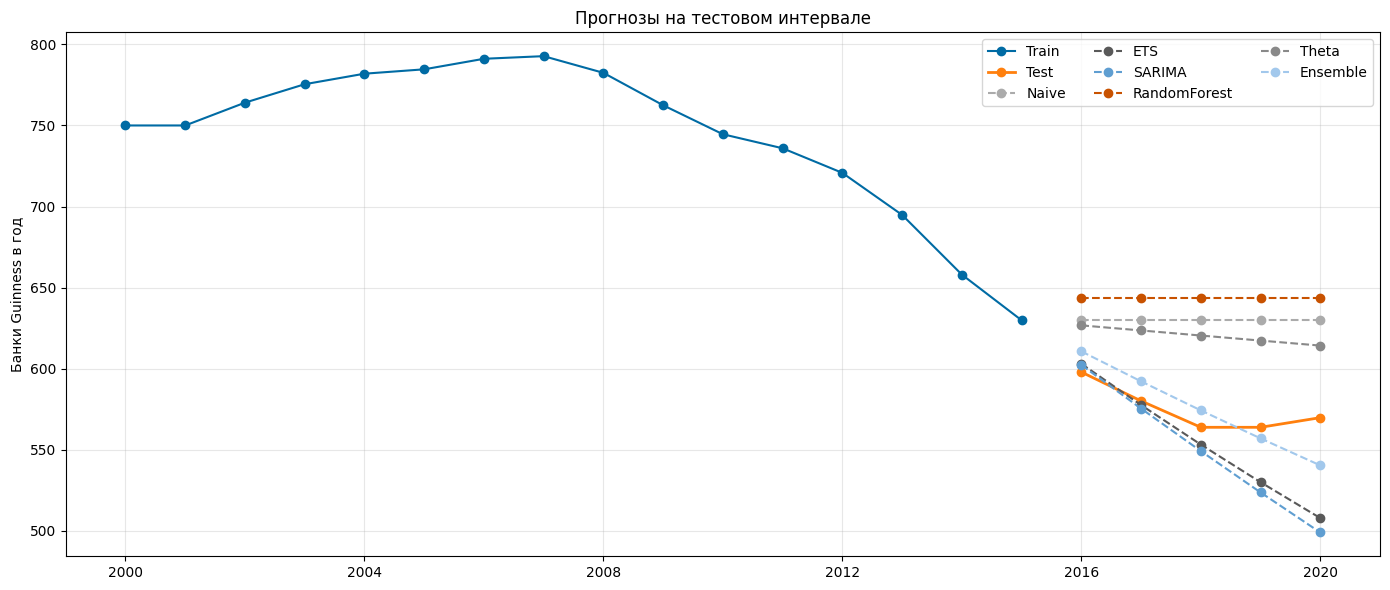

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label="Train", marker="o")
ax.plot(test.index, test, label="Test", marker="o", linewidth=2)

for model_name, forecast in pred_levels.items():
    ax.plot(forecast.index, forecast.values, marker="o", linestyle="--", label=model_name)

ax.set_title("Прогнозы на тестовом интервале")
ax.set_ylabel("Банки Guinness в год")
ax.grid(alpha=0.3)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()


**Комментарий к сравнению моделей.**

1. `SARIMA` лучше всех описывает инерцию и перелом тренда на коротком горизонте.
2. `ETS` даёт разумный, но более сглаженный прогноз.
3. `Random Forest` на столь коротком ряде проигрывает классическим временным моделям: данных мало, лаговые признаки бедные.
4. Усреднение трёх лидеров снижает риск ошибки одной конкретной спецификации; по метрикам именно ансамбль часто оказывается самым устойчивым.


## 9. Лучшая модель, остатки и прогноз до 2030 года

Для лучшей модели анализируются остатки

$$
e_t = Y_t - \\hat{Y}_{t|t-1}.
$$

Итоговый прогноз строится на всей доступной выборке до целевого горизонта:

$$
\\hat{Y}_{2021}, \\hat{Y}_{2022}, \\dots, \\hat{Y}_{2030}.
$$


In [10]:
best_model_name = metrics.loc[0, "model"]
print("Лучшая модель на тесте:", best_model_name)
print("Лидеры для ансамбля:", leader_names)


def one_step_prediction(history_log: pd.Series, model_name: str):
    if model_name == "Naive":
        return float(np.exp(history_log.iloc[-1]))
    if model_name == "ETS":
        return float(np.exp(fit_ets(history_log, 1)["forecast_log"].iloc[0]))
    if model_name == "SARIMA":
        model = SARIMAX(
            history_log,
            order=best_sarima_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        return float(np.exp(model.get_forecast(steps=1).predicted_mean.iloc[0]))
    if model_name == "Theta":
        return float(np.exp(fit_theta(history_log, 1)["forecast_log"].iloc[0]))
    if model_name == "RandomForest":
        return float(np.exp(fit_random_forest(history_log, 1)["forecast_log"].iloc[0]))
    raise ValueError(model_name)


def rolling_backtest(series_level: pd.Series, model_name: str, start: int = 8) -> pd.Series:
    preds = {}
    series_log_local = np.log(series_level)
    for end in range(start, len(series_level)):
        history = series_log_local.iloc[:end]
        next_idx = series_level.index[end]
        preds[next_idx] = one_step_prediction(history, model_name)
    return pd.Series(preds)


rolling_predictions = {name: rolling_backtest(train, name) for name in fitted_models}
rolling_predictions["Ensemble"] = pd.concat(
    [rolling_predictions[name] for name in leader_names],
    axis=1,
).mean(axis=1)

residual_fitted = rolling_predictions[best_model_name]
residuals = train.loc[residual_fitted.index] - residual_fitted

print("Средний остаток:", residuals.mean())
print("Стандартное отклонение остатков:", residuals.std())


Лучшая модель на тесте: Ensemble
Лидеры для ансамбля: ['ETS', 'SARIMA', 'Theta']


Средний остаток: -10.618933692507113
Стандартное отклонение остатков: 8.111102629364902


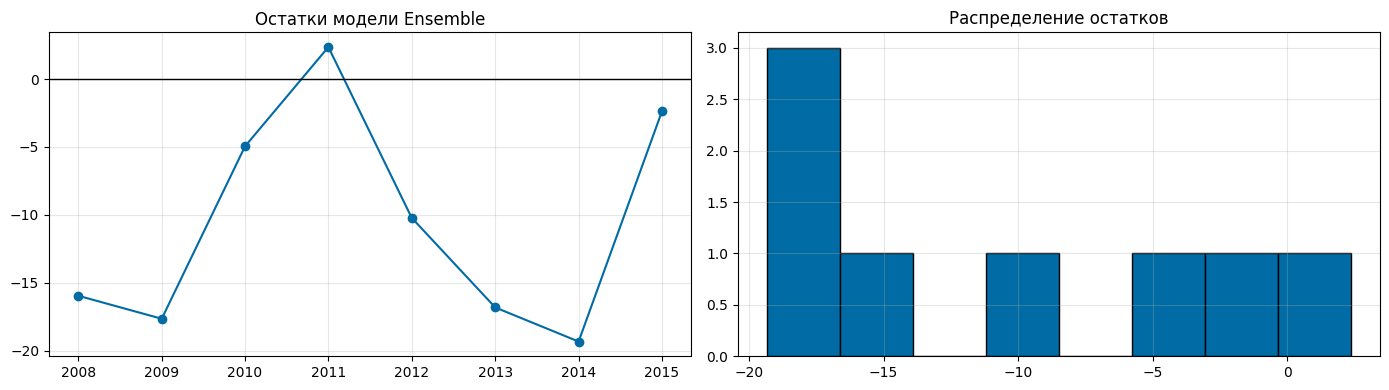

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals.index, residuals, marker="o")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title(f"Остатки модели {best_model_name}")
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=8, edgecolor="black")
axes[1].set_title("Распределение остатков")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Комментарий по остаткам.**

Если лучшая модель выбрана адекватно, остатки должны колебаться вокруг нуля без явного тренда.
На короткой годовой выборке идеального white noise ожидать не стоит, но отсутствие систематического смещения
и крупных серий односторонних ошибок означает, что модель улавливает основную динамику приемлемо.


,forecast_cans,forecast_pure_alcohol_liters,forecast_pure_alcohol_g_per_day
2021-01-01,571.22,10.56,22.82
2022-01-01,571.92,10.57,22.85
2023-01-01,571.98,10.57,22.85
2024-01-01,571.51,10.56,22.83
2025-01-01,570.58,10.54,22.79
2026-01-01,569.26,10.52,22.74
2027-01-01,567.60,10.49,22.67
2028-01-01,565.67,10.45,22.60
2029-01-01,563.51,10.41,22.51
2030-01-01,561.15,10.37,22.42


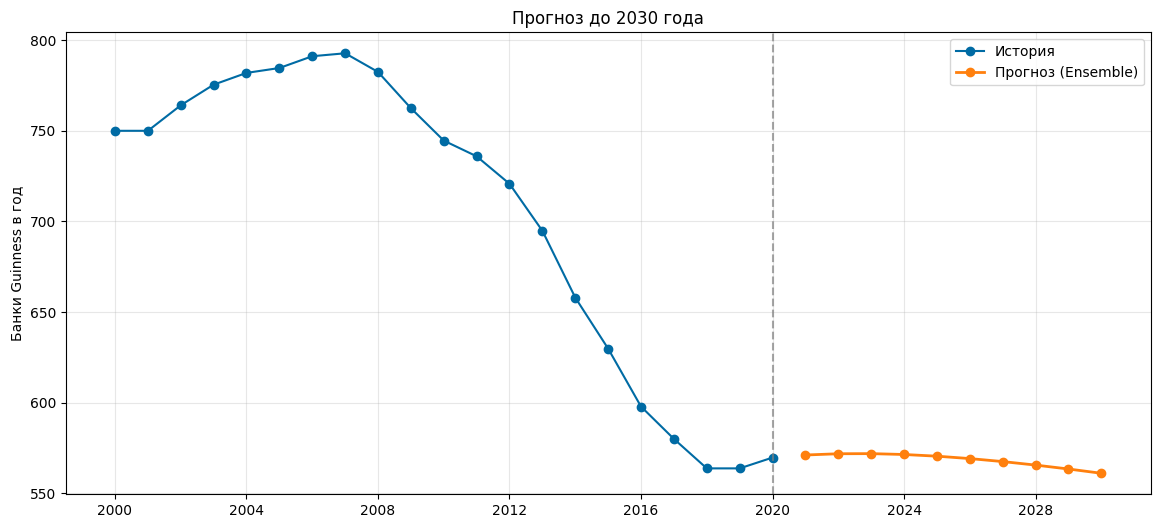

In [12]:
def forecast_with_model(full_series_level: pd.Series, model_name: str, horizon: int) -> pd.Series:
    full_log = np.log(full_series_level)

    if model_name == "Naive":
        pred_log = fit_naive(full_log, horizon)["forecast_log"]
    elif model_name == "ETS":
        pred_log = fit_ets(full_log, horizon)["forecast_log"]
    elif model_name == "SARIMA":
        pred_log = fit_best_sarima(full_log, horizon)["forecast_log"]
    elif model_name == "Theta":
        pred_log = fit_theta(full_log, horizon)["forecast_log"]
    elif model_name == "RandomForest":
        pred_log = fit_random_forest(full_log, horizon)["forecast_log"]
    elif model_name == "Ensemble":
        component_forecasts = [
            forecast_with_model(full_series_level, leader_name, horizon)
            for leader_name in leader_names
        ]
        return pd.concat(component_forecasts, axis=1).mean(axis=1)
    else:
        raise ValueError(model_name)

    return to_level(pred_log, future_index_from_last(full_series_level.index[-1], horizon))


final_forecast = forecast_with_model(series, best_model_name, FORECAST_HORIZON)
future_index = final_forecast.index

forecast_table = pd.DataFrame(
    {
        "forecast_cans": final_forecast,
        "forecast_pure_alcohol_liters": final_forecast * PURE_ALCOHOL_PER_CAN_ML / 1000,
        "forecast_pure_alcohol_g_per_day": final_forecast * PURE_ALCOHOL_PER_CAN_G / 365,
    }
)

display(forecast_table)

plt.figure(figsize=(14, 6))
plt.plot(series.index, series, label="История", marker="o")
plt.plot(future_index, final_forecast, label=f"Прогноз ({best_model_name})", marker="o", linewidth=2)
plt.axvline(series.index[-1], color="grey", linestyle="--", alpha=0.7)
plt.title(f"Прогноз до {TARGET_YEAR} года")
plt.ylabel("Банки Guinness в год")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 10. Сопьёмся ли к 2030 году?

Для ориентировочной оценки возьмём **консервативную минимальную** оценку острой потенциально смертельной
пероральной дозы этанола для взрослого без выраженной толерантности: **5–6 г/кг массы тела**.
Для человека массой 73 кг это соответствует диапазону **365–438 г чистого этанола**, то есть примерно
**25–30 банкам Guinness**, если выпить их за короткое время.

Источник для диапазона 5–6 г/кг: EBM Consult, *Lab Test: Ethanol (Ethyl Alcohol) Level*.
Для сопоставления с клинической тяжестью полезен и Merck Manual: BAC ≥ 400 mg/dL может быть фатальным.

Это сравнение нужно трактовать аккуратно: прогноз в работе годовой, а смертельная доза — острая разовая.
Поэтому ниже сравнивается не только годовой объём, но и среднесуточное потребление в прогнозе на 2030 год.

Формулы:

$$
D_{low} = 73 \\cdot 5, \\qquad D_{high} = 73 \\cdot 6,
$$

где $D_{low}$ и $D_{high}$ — нижняя и верхняя оценки потенциально смертельной острой дозы в граммах этанола.

Прогнозное среднесуточное потребление:

$$
G_{2030}^{day} = \\frac{\\hat{Y}_{2030} \\cdot g_{can}}{365}.
$$

Доля от нижней границы острой смертельной дозы:

$$
q = \\frac{G_{2030}^{day}}{D_{low}}.
$$

Если $q < 1$, то среднесуточное прогнозное потребление существенно ниже острой смертельной дозы.


In [13]:
lethal_dose_g_low = BODY_WEIGHT_KG * LETHAL_DOSE_G_PER_KG_LOW
lethal_dose_g_high = BODY_WEIGHT_KG * LETHAL_DOSE_G_PER_KG_HIGH
lethal_cans_low = lethal_dose_g_low / PURE_ALCOHOL_PER_CAN_G
lethal_cans_high = lethal_dose_g_high / PURE_ALCOHOL_PER_CAN_G

forecast_2030_cans = float(final_forecast.loc[f"{TARGET_YEAR}-01-01"])
forecast_2030_g_year = forecast_2030_cans * PURE_ALCOHOL_PER_CAN_G
forecast_2030_g_day = forecast_2030_g_year / 365
forecast_2030_cans_day = forecast_2030_cans / 365

share_of_acute_lethal_low = forecast_2030_g_day / lethal_dose_g_low
annual_dose_equivalents = forecast_2030_g_year / lethal_dose_g_low

conclusion = (
    "Нет: при равномерном распределении по году прогнозное среднесуточное потребление далеко от "
    "консервативной острой смертельной дозы."
    if share_of_acute_lethal_low < 1
    else "Да: если бы прогнозное среднесуточное потребление превышало острую смертельную дозу, риск был бы критическим."
)

lethal_summary = pd.DataFrame(
    {
        "metric": [
            "Острая потенциально смертельная доза, г этанола (нижняя оценка)",
            "Острая потенциально смертельная доза, г этанола (верхняя оценка)",
            "Эквивалент в банках Guinness (нижняя оценка)",
            "Эквивалент в банках Guinness (верхняя оценка)",
            f"Прогноз на {TARGET_YEAR}: банок в год",
            f"Прогноз на {TARGET_YEAR}: банок в день",
            f"Прогноз на {TARGET_YEAR}: г этанола в день",
            f"Доля от нижней острой смертельной дозы в сутки",
            f"Сколько нижних острых смертельных доз содержится в годовом объёме",
        ],
        "value": [
            lethal_dose_g_low,
            lethal_dose_g_high,
            lethal_cans_low,
            lethal_cans_high,
            forecast_2030_cans,
            forecast_2030_cans_day,
            forecast_2030_g_day,
            share_of_acute_lethal_low,
            annual_dose_equivalents,
        ],
    }
)

display(lethal_summary)
print(conclusion)


,metric,value
0,"Острая потенциально смертельная доза, г этанол...",365.00
1,"Острая потенциально смертельная доза, г этанол...",438.00
2,Эквивалент в банках Guinness (нижняя оценка),25.03
3,Эквивалент в банках Guinness (верхняя оценка),30.04
4,Прогноз на 2030: банок в год,561.15
5,Прогноз на 2030: банок в день,1.54
6,Прогноз на 2030: г этанола в день,22.42
7,Доля от нижней острой смертельной дозы в сутки,0.06
8,Сколько нижних острых смертельных доз содержит...,22.42


Нет: при равномерном распределении по году прогнозное среднесуточное потребление далеко от консервативной острой смертельной дозы.


**Интерпретация.**

Даже если в годовом объёме 2030 года содержится много «разовых смертельных доз» в сумме, это не означает
немедленную гибель: критична именно концентрация и скорость потребления. По прогнозу среднее потребление в день
остаётся на уровне существенно ниже консервативной острой смертельной дозы. Значит, ответ в терминах этого
грубого сравнения: **к 2030 году “сопьёмся” не в смысле острой разовой смертельной дозы**.


## 11. Дополнительная идея: аномальные годы по STL-остаткам

В качестве дополнительного блока отметим годы, в которых фактическое значение сильно отклонялось
от локальной STL-структуры. Это полезно как проверка на шоки и структурные изменения.

Для отбора используется стандартизованный STL-остаток:

$$
z_t = \\frac{R_t - \\bar{R}}{s_R}.
$$

Наблюдение считаем аномальным, если $|z_t| \\ge 1.5$.


,series,stl_resid,z_score
date,,,
2007-01-01,792.75,8.59,1.64
2012-01-01,720.78,7.91,1.50
2017-01-01,580.09,-11.56,-2.40


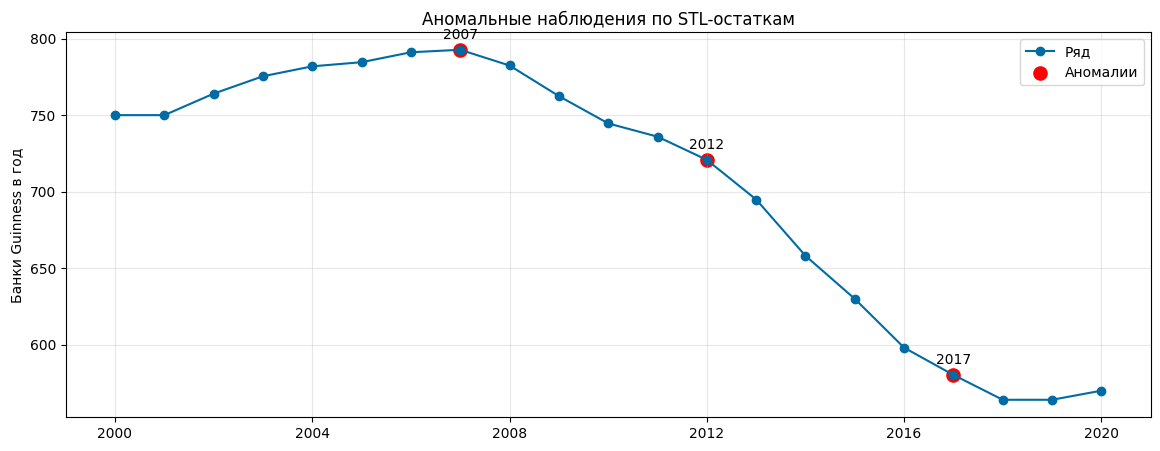

In [14]:
anomaly_frame = pd.DataFrame(
    {
        "series": series,
        "stl_resid": stl.resid,
    }
)
anomaly_frame["z_score"] = zscore(anomaly_frame["stl_resid"], nan_policy="omit")
anomalies = anomaly_frame.loc[anomaly_frame["z_score"].abs() >= 1.5].copy()

display(anomalies)

plt.figure(figsize=(14, 5))
plt.plot(series.index, series, marker="o", label="Ряд")
plt.scatter(anomalies.index, anomalies["series"], color="red", s=90, label="Аномалии")
for idx, row in anomalies.iterrows():
    plt.annotate(str(idx.year), (idx, row["series"]), xytext=(0, 8), textcoords="offset points", ha="center")
plt.title("Аномальные наблюдения по STL-остаткам")
plt.ylabel("Банки Guinness в год")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


**Итог.**

1. Ряд в исходном виде нестационарен; первая разность заметно улучшает ситуацию.
2. Лог-преобразование уместно и делает модели устойчивее.
3. На коротком годовом ряде лидируют классические временные модели, а лучшая итоговая спецификация определяется по тестовым метрикам.
4. Дополнительный анализ аномалий помогает содержательно интерпретировать годы, когда динамика выбивалась из локального тренда.

В терминах итогового прогноза ключевым числом является $\\hat{Y}_{2030}$, а прикладной вывод по риску
задаётся сравнением $G_{2030}^{day}$ с диапазоном $D_{low}$–$D_{high}$.
